# **STAGE 3 - MACHINE LEARNING**

## **Objectives**

* In this notebook, I am going to build and compare machine learning models capable of predicting students' final exam scores (`final_exam_score`) based on academic, behavioural and demographic features.

## **Inputs**

* The input needed for this notebook is the cleaned dataset created in **Stage 1 - ETL**. 
* The relative path for this .csv file is: `datasets/cleaned-data/student_performance_dataset_cleaned.csv`.
* In the notebook, I will outline which variables will be used as features (`X`) for the machine learning models.

## **Outputs**

* The output of this notebook will be three machine learning models fitted and evaluated on their effectiveness in predicting the target variable `final_exam_score`.

---

## **Change working directory**

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/elliebrawn/Documents/vscode-projects/student-performance-analysis/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/elliebrawn/Documents/vscode-projects/student-performance-analysis'

---

## **Import Packages and Libraries**

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# Import Scikit-learn Pipeline
from sklearn.pipeline import Pipeline

# Import ColumnTransformer, which is used to apply different preprocessing steps to different columns of the dataset
from sklearn.compose import ColumnTransformer

# Import OneHotEncoder, which is used to convert categorical variables into binary vectors (one-hot encoding)
from sklearn.preprocessing import OneHotEncoder

# Import StandardScaler, which is used to standardise numerical data to make sure the data points have a balanced scale
from sklearn.preprocessing import StandardScaler

# Import SelectFromModel, which is used for feature selection based on the importance of features determined by a model
from sklearn.feature_selection import SelectFromModel

# Import ML Algorithm Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Import regression metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error 

---

## **Load Dataset**

First, I will load the cleaned dataset `student_performance_dataset_cleaned.csv`.

In [5]:
# Load the cleaned dataset
df_ml = pd.read_csv("datasets/cleaned-data/student_performance_dataset_cleaned.csv")

# Display the first few rows of the dataset to make sure the data has loaded correctly
df_ml.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade,final_grade_category,final_grade_binary
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A,High Grade,1
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A,High Grade,1
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A,High Grade,1
3,4,Male,2.6,77.5,8.0,Unknown,Yes,Yes,No,85.1,83.8,B,High Grade,1
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D,Low Grade,0


---

## **1. Machine Learning Algorithm Selection**

### **1.1 Review the Target Variable**

The first thing I am going to do is decide what machine learning algorithms are going to be appropriate to predict the target.

| **What are you predicting?** | **Target Variable?** | **Algorithm Type** | **Examples** |
| ----- | ----- | ----- | ----- |
| Continuous Number | Yes | Regression Algorithm | Linear Regression, Decision Tree Regression, Random Forest Regression|
| Category | Yes | Classification Algorithm | Logistic Regression, Decision Tree Classification, Random Forest Classification |
| Category | No | Clustering Algorithm | K-Means Clustering |

In [6]:
# Verify what datatype the target variable is
df_ml["final_exam_score"].dtype

if df_ml["final_exam_score"].dtype == "object":
    print("The target variable is categorical.")
elif df_ml["final_exam_score"].dtype == "int64":
    print("The target variable is numerical.")
elif df_ml["final_exam_score"].dtype == "float64":
    print("The target variable is numerical.")
else:
    print("The target variable type is not expected.")

The target variable is numerical.


### **1.2 Algorithm Selection**

Given that the target variable is numerical, this gives a clear picture of what algorithms we can use.

In finding the best model to predict `final_exam_score`, I am going to test **Linear Regression**, **Decision Tree Regression** and **Random Forest Regression**.

---

## **2. Split the Dataset into Test and Train**

### **2.1 Define X and y**

Firstly, I am going to define X and y: in machine learning, X represents the input features and y represents the target.

For our model, `final_exam_score` is our chosen target variable - X. 

I have chosen to not include the following variables as features - y:
`student_id`: this acts as a label for each student and carries no insight beyond being a form of indexing.
`final_grade`: as explored in the EDA section of **Stage 2 - Visualisation** this is very closely correlated to our target variable and would lead to considerable *target leakage*
`final_grade_category` and `final_grade_binary`: these were groups created from `final_grade` in the feature engineering section of **Stage 1 - ETL** and would therefore also train the model with a direct indicator of the target. 

In [7]:
# Define X as the features that will be ussed to train the model
X = df_ml[[
    "gender",
    "study_time_hours",
    "attendance_percent",
    "sleep_hours",
    "parental_education",
    "internet_access",
    "extracurricular_activities",
    "part_time_job",
    "previous_grade"
]]

# Define y as the target variable that we want to predict
y = df_ml["final_exam_score"]

### **2.2 Split the Dataset**

To split the dataset, I am going to use `test_train_split` from scikit-learn (`sklearn`) to separate the data into a train set (80% of the overall dataset) and a test set (20% of the overall dataset).

In [8]:
# Use test_train_split to split the data into a test set (20%) and a train set (80%)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"The dataset has been split into a Train set and a Test set.\n"
      f"Train set: {X_train.shape}, {y_train.shape}\n"
      f"Test set: {X_test.shape}, {y_test.shape}")

The dataset has been split into a Train set and a Test set.
Train set: (800, 9), (800,)
Test set: (200, 9), (200,)


> *Troubleshooting Issue*:
<br><br>When first splitting the test and train sets , I included `X=` and `y=` as parameters, which threw up an error. However, when I looked more closely at the documentation for train_test_split, I noted that these actually needed to just be arrays.
<br><br>Including all the features in a list (for `X` in particular) felt quite difficult to follow, so I decided instead to first **Define X and y** and then parse these two variables into the  `train_test_split()` method.

---

## **3. Separate Categorical and Numerical Features**

In order to implement a Machine Learning Pipeline, I first need to separate my features into numerical vs categorical features. This allows me to perform the correct feature engineering/ feature scaling steps on the data.

In [9]:
# Select the categorical features from X
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

# Select the numerical features from X
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Ensure that this step has been completed correctly by printing the categorical and numerical features
print(f"The categorical features are: {categorical_features}")
print(f"The numeric features are: {numeric_features}")

The categorical features are: ['gender', 'parental_education', 'internet_access', 'extracurricular_activities', 'part_time_job']
The numeric features are: ['study_time_hours', 'attendance_percent', 'sleep_hours', 'previous_grade']


The output of this process gives me the results I am looking for.

---

## **4. Linear Regression**

### **4.1 Outline the Machine Learning Pipeline**

> *Notes on Process*: <br><br>Credit is due to the Code Institute LMS for the instructions on creating a pipeline using a method and linking feature engineering, feature scaling, feature selection altogether in one code block.
<br><br>I had originally planned to do all the steps separately but I found it much harder to follow and thus more prone to errors.
<br><br>Additionally to what was taught in the LMS, I used Generative AI (Claude Sonnet 5), to provide me a simplified breakdown of all the steps in a machine learning pipeline and one of the additional tools I was able to learn about was `ColumnTransformer`.
<br><br>According to the [ColumnTransformer]() Scikit-learn documentation, it allows different columns or column subsets of the input to be transformed separately - this will be useful because I have some categorical and some numeric column values as my features.

In [10]:
# Create a function to create a Machine Learning Pipeline for Linear Regression
def pipeline_linear_regression():
    """
    Create a Machine Learning Pipeline for Linear Regression.
    
    This function creates a machine learning pipeline, during which the following
    steps are performed:

        1. Feature Engineering
            Preprocessor step established with Column Transformer
            Performs two steps:
            a) Feature Engineering with OneHotEncoder for categorical features
            b) Feature Scaling with StandardScaler for numeric features
        2. Modelling with LinearRegression
    
    The function returns:
        pipeline_lr: The pipeline object that performs the specified steps.
    """

    # Create a ColumnTransformer to apply OneHotEncoder to categorical features and StandardScaler to numeric features
    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ("num", StandardScaler(), numeric_features)
        ]
    )

    # Create a pipeline that includes the preprocessor, feature selection, and the Linear Regression model
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ])

    return pipeline

> *Troubleshooting Issues*:
<br><br>When I first put this pipeline together, I followed the example in the LMS which used the `SelectFromModel(LinearRegression())` feature selection step (I have markdown code below to show the original pipeline steps).
<br><br>When it came to evaluating this Linear Regression Model, it appeared that the feature selection stage had actually made the model fit more poorly.
<br><br>Going back and removing the `SelectFromModel(LinearRegression())` step significantly improved the performance of the model.

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("feature_selection", SelectFromModel(LinearRegression())),
        ("model", LinearRegression())
    ])

### **4.2 Fit the Pipeline**

Now is time to fit the pipeline, which allows the model to learn the relationships between the features and the target.

In [11]:
# Fit the Linear Regression Pipeline to the training data using the estimator .fit()
pipeline_lr = pipeline_linear_regression()
pipeline_lr.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender',
                                                   'parental_education',
                                                   'internet_access',
                                                   'extracurricular_activities',
                                                   'part_time_job']),
                                                 ('num', StandardScaler(),
                                                  ['study_time_hours',
                                                   'attendance_percent',
                                                   'sleep_hours',
                                                   'previous_grade'])])),
                ('model', LinearRegression())])

### **4.3 Evaluate the Model**

In this evaluation section (and in the subsequent I will use for Decision Tree Regression and Random Forest Regression), I will be looking at four **Model Evalusation Metrics**:

| **Model Evaluation Metric** | **Explanation** | **Scale/ Units** | **Best Direction** |
| --------------------------- | ----------------| ---------------- | ------------------ |
| **R²** | Tells us how much of the variation in our target (in this case `final_exam_score`) the model is able to explain using the predictors given to it | 0 to 1 in most cases, although it can go below 0 | The closer to 1 the better (closer to 100% explainable variation) |
| **MAE (Mean Absolute Error)** | Tells us, on average, how far off the model's predictions are from the actual exam scores | Same units as the target variable | Lower is better - an MAE of 0 would mean perfect predictions every time |
| **MSE (Mean Squared Error)** | This is similar to MAE, but each error is squared before averaging, meaning bigger errors are punished more than smaller errors (e.g. 1 x 10-point error = 100 vs 2 x 5-point errors = 50) | Same units as the target variable but squared, making it quite hard to interpret | Lower is better |
| **RMSE (Root Mean Squared)** | This is the square-root of MSE, making the units more easily interpreted but still punishes the big errors | Same units as the target variable | Lower is better |

In [14]:
# Step 1: Make Predictions

prediction_train_lr = pipeline_lr.predict(X_train)

prediction_test_lr = pipeline_lr.predict(X_test)

# Step 2: Evaluate the Training Set

train_lr_r2 = r2_score(y_train, prediction_train_lr)
train_lr_mae = mean_absolute_error(y_train, prediction_train_lr)
train_lr_mse = mean_squared_error(y_train, prediction_train_lr)
train_lr_rmse = np.sqrt(train_lr_mse)

print("="*40)
print("LINEAR REGRESSION - TRAIN SET EVALUATION")
print("="*40)
print(f"R²: {train_lr_r2.round(3)}")
print(f"MAE: {train_lr_mae.round(3)}")
print(f"MSE: {train_lr_mse.round(3)}")
print(f"RMSE: {train_lr_rmse.round(3)}")
print("")

# Step 3: Evaluate the Test Set

test_lr_r2 = r2_score(y_test, prediction_test_lr)
test_lr_mae = mean_absolute_error(y_test, prediction_test_lr)
test_lr_mse = mean_squared_error(y_test, prediction_test_lr)
test_lr_rmse = np.sqrt(test_lr_mse)

print("="*40)
print("LINEAR REGRESSION - TEST SET EVALUATION")
print("="*40)
print(f"R²: {test_lr_r2.round(3)}")
print(f"MAE: {test_lr_mae.round(3)}")
print(f"MSE: {test_lr_mse.round(3)}")
print(f"RMSE: {test_lr_rmse.round(3)}")
print("")

LINEAR REGRESSION - TRAIN SET EVALUATION
R²: 0.674
MAE: 4.691
MSE: 34.557
RMSE: 5.879

LINEAR REGRESSION - TEST SET EVALUATION
R²: 0.617
MAE: 4.98
MSE: 41.2
RMSE: 6.419



### **4.4 Plot the Linear Regression**

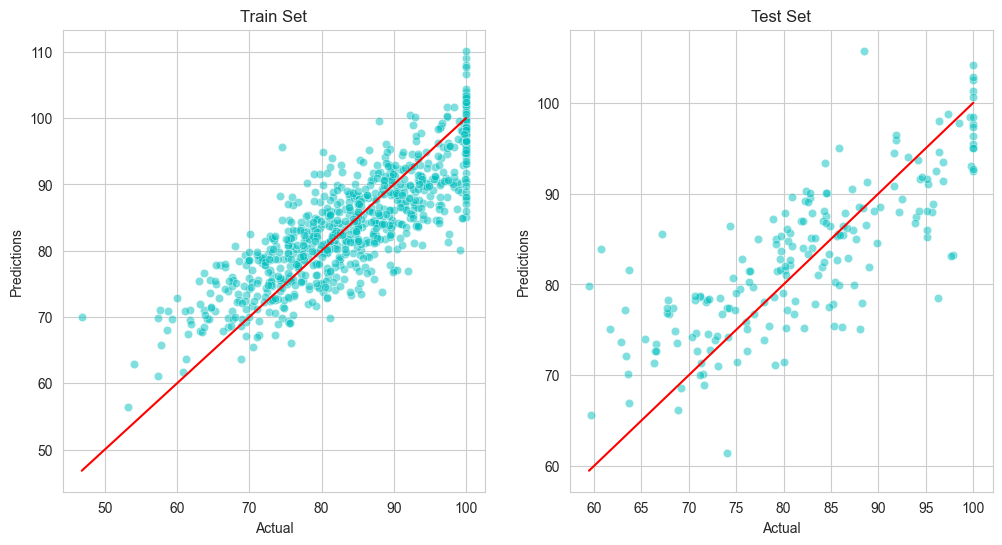

In [16]:
# Plot the Linear Regression Performance on Scatter Plots

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

sns.scatterplot(x=y_train, y=prediction_train_lr, color="c", alpha=0.5, ax=axes[0])
sns.lineplot(x=y_train, y=y_train, color="red", ax=axes[0])
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predictions")
axes[0].set_title("Train Set")

sns.scatterplot(x=y_test, y=prediction_test_lr, color="c", alpha=0.5, ax=axes[1])
sns.lineplot(x=y_test, y=y_test, color="red", ax=axes[1])
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predictions")
axes[1].set_title("Test Set")

plt.show()

### **4.5 Summary of Linear Regression Model Performance**

---

## **5. Decision Tree Regression**

### **5.1 Outline the Machine Learning Pipeline**

> *Notes on Process*:
<br><br>As with the pipeline method I created for Linear Regression, I have to once again give credit to Code Institute for instructions on defining a pipeline and its steps by creating a method.
<br><br>As before, I have used `ColumnTransformer`.

In [19]:
# Create a function to create a Machine Learning Pipeline for Decision Tree Regression
def pipeline_decision_tree_regression():
    """
    Create a Machine Learning Pipeline for Decision Tree Regression.
    
    This function creates a machine learning pipeline, during which the following
    steps are performed:

        1. Feature Engineering
            Preprocessor step established with Column Transformer
            Performs two steps:
            a) Feature Engineering with OneHotEncoder for categorical features
            b) Feature Scaling with StandardScaler for numeric features
        2. Feature Selection with SelectFromModel
        3. Modelling with Random Forest Regression
    
    The function returns:
        pipeline (Pipeline): The pipeline object that performs the specified steps.
    """

    # Create a ColumnTransformer to apply OneHotEncoder to categorical features and StandardScaler to numeric features
    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ("num", StandardScaler(), numeric_features)
        ]
    )

    # Create a pipeline that includes the preprocessor, feature selection, and the Linear Regression model
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(random_state=42))
    ])

    return pipeline

### **5.2 Fit the Pipeline**

In [20]:
# Fit the Decision Tree Pipeline to the training data using the estimator .fit()
pipeline_dt = pipeline_decision_tree_regression()
pipeline_dt.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender',
                                                   'parental_education',
                                                   'internet_access',
                                                   'extracurricular_activities',
                                                   'part_time_job']),
                                                 ('num', StandardScaler(),
                                                  ['study_time_hours',
                                                   'attendance_percent',
                                                   'sleep_hours',
                                                   'previous_grade'])])),
                ('model', DecisionTreeRegressor(random_state=42))])

### **5.3 Evaluate the Model**

In [24]:
# Step 1: Make Predictions

prediction_train_dt = pipeline_dt.predict(X_train)

prediction_test_dt = pipeline_dt.predict(X_test)

# Step 2: Evaluate the Training Set

train_dt_r2 = r2_score(y_train, prediction_train_dt)
train_dt_mae = mean_absolute_error(y_train, prediction_train_dt)
train_dt_mse = mean_squared_error(y_train, prediction_train_dt)
train_dt_rmse = np.sqrt(train_dt_mse)

print("="*37)
print("DECISION TREE - TRAIN SET EVALUATION")
print("="*37)
print(f"R²: {train_dt_r2.round(3)}")
print(f"MAE: {train_dt_mae.round(3)}")
print(f"MSE: {train_dt_mse.round(3)}")
print(f"RMSE: {train_dt_rmse.round(3)}")
print("")

# Step 3: Evaluate the Test Set

test_dt_r2 = r2_score(y_test, prediction_test_dt)
test_dt_mae = mean_absolute_error(y_test, prediction_test_dt)
test_dt_mse = mean_squared_error(y_test, prediction_test_dt)
test_dt_rmse = np.sqrt(test_dt_mse)

print("="*37)
print("DECISION TREE - TEST SET EVALUATION")
print("="*37)
print(f"R²: {test_dt_r2.round(3)}")
print(f"MAE: {test_dt_mae.round(3)}")
print(f"MSE: {test_dt_mse.round(3)}")
print(f"RMSE: {test_dt_rmse.round(3)}")
print("")

DECISION TREE - TRAIN SET EVALUATION
R²: 1.0
MAE: 0.0
MSE: 0.0
RMSE: 0.0

DECISION TREE - TEST SET EVALUATION
R²: 0.171
MAE: 7.33
MSE: 89.22
RMSE: 9.446



### **5.4 Summary of Decision Tree Regression Model Performance**

---

## **6. Random Forest Regression**

### **6.1 Outline the Machine Learning Pipeline**

In [25]:
# Create a function to create a Machine Learning Pipeline for Random Forest Regression
def pipeline_random_forest_regression():
    """
    Create a Machine Learning Pipeline for Random Forest Regression.
    
    This function creates a machine learning pipeline, during which the following
    steps are performed:

        1. Feature Engineering
            Preprocessor step established with Column Transformer
            Performs two steps:
            a) Feature Engineering with OneHotEncoder for categorical features
            b) Feature Scaling with StandardScaler for numeric features
        2. Feature Selection with SelectFromModel
        3. Modelling with Random Forest Regression
    
    The function returns:
        pipeline (Pipeline): The pipeline object that performs the specified steps.
    """

    # Create a ColumnTransformer to apply OneHotEncoder to categorical features and StandardScaler to numeric features
    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ("num", StandardScaler(), numeric_features)
        ]
    )

    # Create a pipeline that includes the preprocessor, feature selection, and the Linear Regression model
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=42, n_estimators=100))
    ])

    return pipeline

### **6.2 Fit the Pipeline**

In [26]:
# Fit the Random Forest Pipeline to the training data using the estimator .fit()
pipeline_rf = pipeline_random_forest_regression()
pipeline_rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender',
                                                   'parental_education',
                                                   'internet_access',
                                                   'extracurricular_activities',
                                                   'part_time_job']),
                                                 ('num', StandardScaler(),
                                                  ['study_time_hours',
                                                   'attendance_percent',
                                                   'sleep_hours',
                                                   'previous_grade'])])),
                ('model', RandomForestRegressor(random_state=42))])

### **6.3 Evaluate the Model**

In [28]:
# Step 1: Make Predictions

prediction_train_rf = pipeline_rf.predict(X_train)

prediction_test_rf = pipeline_rf.predict(X_test)

# Step 2: Evaluate the Training Set

train_rf_r2 = r2_score(y_train, prediction_train_rf)
train_rf_mae = mean_absolute_error(y_train, prediction_train_rf)
train_rf_mse = mean_squared_error(y_train, prediction_train_rf)
train_rf_rmse = np.sqrt(train_rf_mse)

print("="*37)
print("RANDOM FOREST - TRAIN SET EVALUATION")
print("="*37)
print(f"R²: {train_rf_r2.round(3)}")
print(f"MAE: {train_rf_mae.round(3)}")
print(f"MSE: {train_rf_mse.round(3)}")
print(f"RMSE: {train_rf_rmse.round(3)}")
print("")

# Step 3: Evaluate the Test Set

test_rf_r2 = r2_score(y_test, prediction_test_rf)
test_rf_mae = mean_absolute_error(y_test, prediction_test_rf)
test_rf_mse = mean_squared_error(y_test, prediction_test_rf)
test_rf_rmse = np.sqrt(test_rf_mse)

print("="*37)
print("RANDOM FOREST - TEST SET EVALUATION")
print("="*37)
print(f"R²: {test_rf_r2.round(3)}")
print(f"MAE: {test_rf_mae.round(3)}")
print(f"MSE: {test_rf_mse.round(3)}")
print(f"RMSE: {test_rf_rmse.round(3)}")
print("")

RANDOM FOREST - TRAIN SET EVALUATION
R²: 0.94
MAE: 1.964
MSE: 6.336
RMSE: 2.517

RANDOM FOREST - TEST SET EVALUATION
R²: 0.562
MAE: 5.324
MSE: 47.168
RMSE: 6.868



### **6.4 Summary of Random Forest Regression Model Performance**

---